# Sentinel-2 Land Cover Classification with CNN Transfer Learning
## Foundation for Earth Observation-Based Poverty Proxy Estimation

**Author:** Puja Poudel &nbsp;|&nbsp; **Dataset:** EuroSAT RGB (Sentinel-2) &nbsp;|&nbsp; **Model:** ResNet-18 Transfer Learning

---

### Purpose

This notebook demonstrates a complete deep-learning pipeline applied to Sentinel-2 satellite imagery.
It is designed as a technical foundation for doctoral research in EO-based poverty estimation.

The pipeline covers:
- Automated acquisition of open Sentinel-2 imagery (EuroSAT dataset, 27,000 labelled patches)
- Transfer learning with a pretrained ResNet-18 CNN
- Two-phase training: frozen backbone → selective fine-tuning
- Per-class evaluation and normalised confusion matrix
- GradCAM attribution maps showing which spatial features drive predictions
- A discussion connecting land cover classification to poverty proxy estimation

### Why EuroSAT?

EuroSAT is a benchmark dataset of **27,000 Sentinel-2 image patches** (64 × 64 px, RGB) covering
**10 land cover classes** across European territory. It is freely available, small enough to train
on Colab's free GPU tier in under 15 minutes, and uses the same Sentinel-2 sensor family
that the AI and Global Development Lab applies for poverty mapping in Sub-Saharan Africa.

### Connection to Poverty Estimation

Land cover classification is a **prerequisite capability** for EO-based poverty proxy estimation.
Spectral and spatial features that distinguish Residential from Industrial from Bare Soil patches
are the same feature families that poverty estimation models use as wealth index proxies
(building density, road access, vegetation cover, nightlight intensity).
The GradCAM attribution maps trained here directly parallel the explainability requirements
of the target doctoral project.

---

### Table of Contents
1. [Environment Setup](#1.-Environment-Setup)
2. [Data Acquisition — EuroSAT (Sentinel-2)](#2.-Data-Acquisition)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
4. [Data Preprocessing Pipeline](#4.-Data-Preprocessing-Pipeline)
5. [Model Architecture — ResNet-18 Transfer Learning](#5.-Model-Architecture)
6. [Training — Phase 1: Frozen Backbone](#6.-Training-Phase-1)
7. [Training — Phase 2: Selective Fine-Tuning](#7.-Training-Phase-2)
8. [Evaluation on Held-Out Test Set](#8.-Evaluation)
9. [GradCAM Attribution Maps](#9.-GradCAM-Attribution-Maps)
10. [From Land Cover to Poverty Proxies](#10.-From-Land-Cover-to-Poverty-Proxies)
11. [Next Steps](#11.-Next-Steps)

## 1. Environment Setup

> **Before running:** Select `Runtime → Change runtime type → T4 GPU` in Google Colab.
> Training is ~10× faster on GPU. The notebook runs on CPU but will take ~30 min.

In [ ]:
# Install additional packages not pre-installed in Colab
# pytorch-grad-cam : GradCAM attribution maps
# All other packages (torch, torchvision, sklearn, seaborn) are pre-installed
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=7ed0e057fc7fa78bb257820fa06d12c1e8691303a78c84e5ba583e24890e990e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import os, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import EuroSAT

from sklearn.metrics import classification_report, confusion_matrix

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.manual_seed(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Running on CPU — consider switching to GPU runtime for faster training')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')

GPU: Tesla T4
GPU Memory: 15.6 GB
PyTorch version : 2.11.0+cu128
Device          : cuda


## 2. Data Acquisition

### EuroSAT Dataset

| Property | Value |
|---|---|
| Sensor | Sentinel-2 (ESA Copernicus Programme) |
| Patches | 27,000 (RGB, 64 × 64 pixels) |
| Classes | 10 land cover types |
| Download | Auto via `torchvision.datasets.EuroSAT` (~89 MB) |
| Licence | MIT |

The 10 classes cover a spectrum of land use intensities that correlate with socioeconomic
activity — from `Forest` and `Pasture` (low human modification) through `Residential`
and `Industrial` (high human modification). This gradient is directly analogous to the
wealth-index proxies used in satellite-based poverty estimation.

> **Geographic note:** EuroSAT patches were sampled from across Europe.
> The Sentinel-2 sensor specifications (13 spectral bands, 10 m resolution) are identical
> to those used for African poverty mapping. The RGB subset used here corresponds to
> bands B4 (Red), B3 (Green), B2 (Blue).

In [ ]:
# ── Dataset constants ────────────────────────────────────────────────────
CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]
NUM_CLASSES = len(CLASS_NAMES)

# ── Normalisation ────────────────────────────────────────────────────────
# ImageNet statistics — standard when fine-tuning pretrained ResNet.
# EuroSAT-specific statistics (mean=[0.344,0.380,0.408], std=[0.203,0.137,0.115])
# can be substituted for domain-specific pre-training experiments.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transform pipeline ───────────────────────────────────────────────────
# EuroSAT images are 64×64 px. We resize to 224×224 so that pretrained
# ResNet-18 feature maps retain sufficient spatial resolution for GradCAM.
# Upsampling from 64→224 uses bilinear interpolation; this is standard
# practice for transfer learning on small-patch satellite datasets.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Raw transform for visualisation only (no normalisation)
vis_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ── Download ─────────────────────────────────────────────────────────────
print('Downloading EuroSAT RGB dataset (~89 MB)...')
try:
    full_dataset = EuroSAT(root='./data', download=True, transform=eval_transform)
    print(f'Download complete. Total samples : {len(full_dataset):,}')
    print(f'Classes ({NUM_CLASSES})           : {full_dataset.classes}')
except Exception as e:
    print(f'Download error: {e}')
    print('Tip: Check your internet connection or restart the Colab runtime.')
    raise

100%|██████████| 94.3M/94.3M [00:00<00:00, 264MB/s]


Download complete. Total samples : 27,000
Classes (10)           : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Exploratory Data Analysis

We inspect one representative patch per class and the overall class distribution.
EuroSAT is deliberately balanced (~2,000–3,000 samples per class), which simplifies
training but differs from real-world distributions where rare land cover types
(e.g., informal settlements) are systematically under-represented — a challenge
directly relevant to poverty estimation in data-scarce regions.

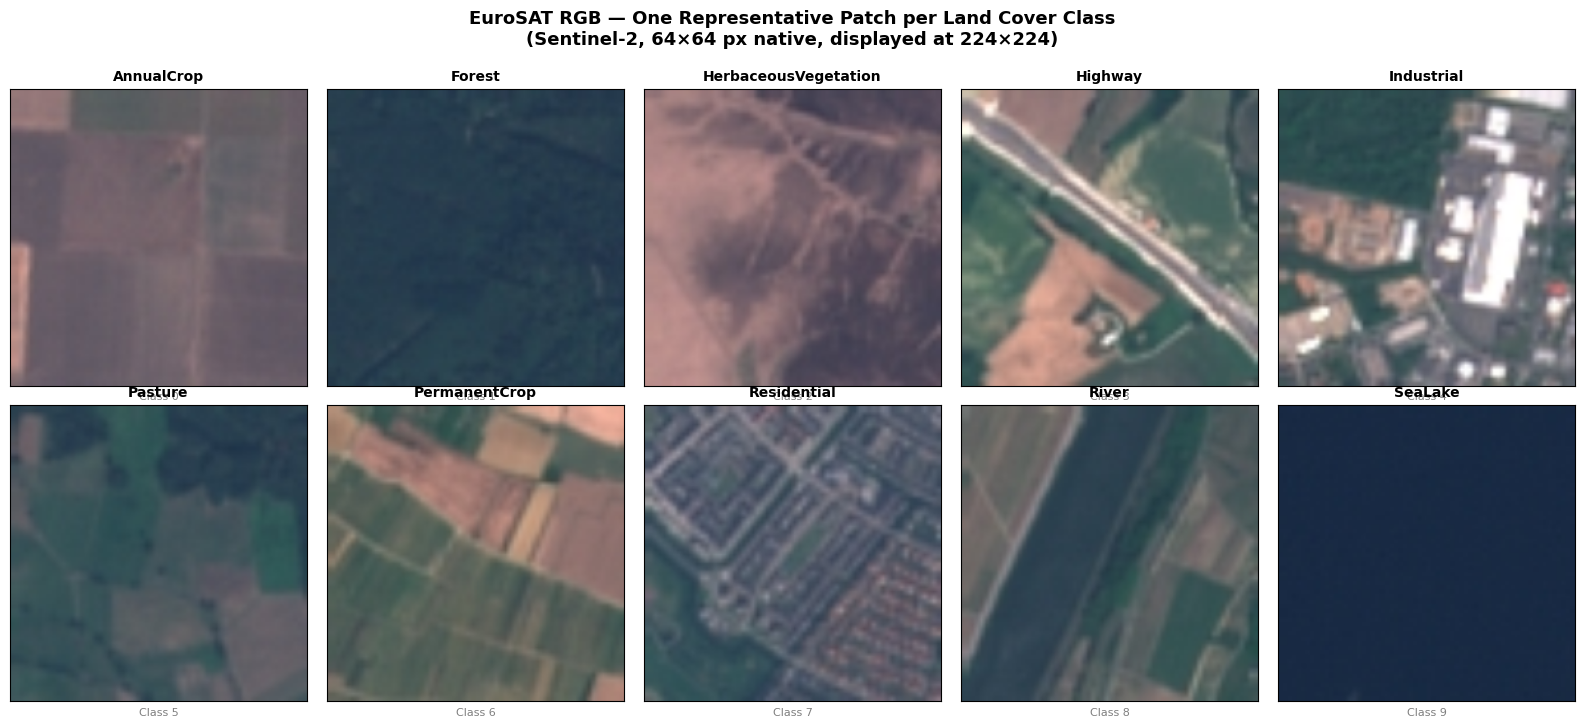

Fig saved: eurosat_samples.png


In [ ]:
# ── Sample images (one per class) ───────────────────────────────────────
vis_dataset = EuroSAT(root='./data', download=False, transform=vis_transform)
targets_all = np.array(vis_dataset.targets)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('EuroSAT RGB — One Representative Patch per Land Cover Class\n'
             '(Sentinel-2, 64×64 px native, displayed at 224×224)',
             fontsize=13, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASS_NAMES):
    # Use first occurrence of each class for reproducibility
    idx = int(np.where(targets_all == i)[0][0])
    img, _ = vis_dataset[idx]
    ax = axes[i // 5, i % 5]
    ax.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Class {i}', fontsize=8, color='grey')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('eurosat_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig saved: eurosat_samples.png')

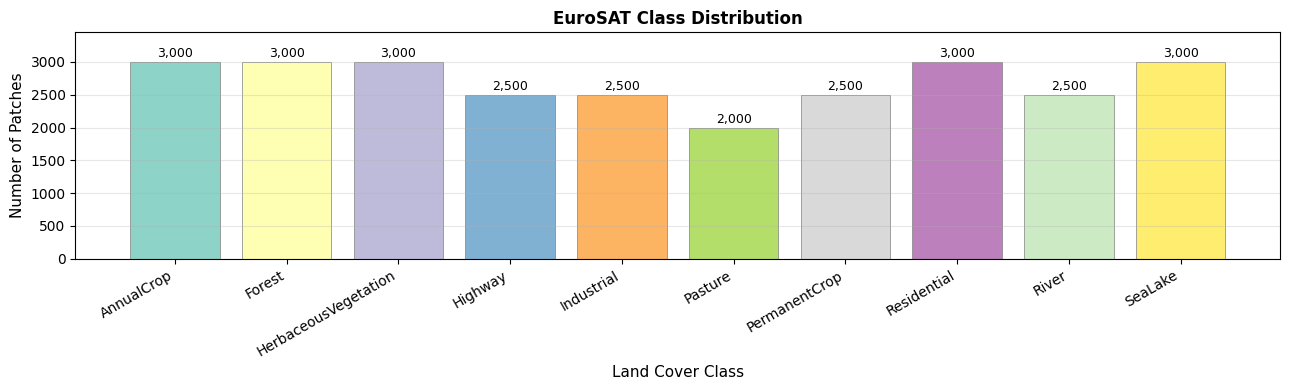

Total patches    : 27,000
Min class count  : 2,000 (Pasture)
Max class count  : 3,000 (AnnualCrop)
Balance ratio    : 0.67 (1.0 = perfectly balanced)


In [ ]:
# ── Class distribution ───────────────────────────────────────────────────
counts = Counter(targets_all)
class_counts = [counts[i] for i in range(NUM_CLASSES)]

colours = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(CLASS_NAMES, class_counts, color=colours, edgecolor='grey', linewidth=0.5)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{count:,}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Land Cover Class', fontsize=11)
ax.set_ylabel('Number of Patches', fontsize=11)
ax.set_title('EuroSAT Class Distribution', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(class_counts) * 1.15)
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total patches    : {sum(class_counts):,}')
print(f'Min class count  : {min(class_counts):,} ({CLASS_NAMES[class_counts.index(min(class_counts))]})')
print(f'Max class count  : {max(class_counts):,} ({CLASS_NAMES[class_counts.index(max(class_counts))]})')
print(f'Balance ratio    : {min(class_counts)/max(class_counts):.2f} (1.0 = perfectly balanced)')

## 4. Data Preprocessing Pipeline

### Train / Validation / Test Split
| Split | Ratio | Purpose |
|---|---|---|
| Train | 70% | Model weight updates |
| Validation | 15% | Hyperparameter tuning, early stopping |
| Test | 15% | Final unbiased evaluation |

### Data Augmentation (training set only)
Random horizontal and vertical flips simulate the rotational invariance of satellite
imagery (a building looks the same from any nadir angle). Colour jitter accounts for
atmospheric and seasonal variation in reflectance — important for generalisation
across seasons and geographic regions.

### Why separate training and evaluation transforms?
Augmentation is applied **only to training data**. Validation and test sets use
the deterministic `eval_transform` to ensure reproducible, unbiased metrics.

In [ ]:
# ── Splits ───────────────────────────────────────────────────────────────
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15
total   = len(full_dataset)
n_train = int(TRAIN_RATIO * total)
n_val   = int(VAL_RATIO * total)
n_test  = total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_idx_ds, val_idx_ds, test_idx_ds = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

# Apply training augmentation to the train split only.
# We re-wrap the train indices against a freshly transformed dataset.
train_full = EuroSAT(root='./data', download=False, transform=train_transform)
from torch.utils.data import Subset
train_ds = Subset(train_full, train_idx_ds.indices)
val_ds   = Subset(full_dataset, val_idx_ds.indices)
test_ds  = Subset(full_dataset, test_idx_ds.indices)

# ── DataLoaders ───────────────────────────────────────────────────────────
# Reduce num_workers to 0 if you encounter 'BrokenPipeError' on Colab.
BATCH_SIZE  = 64 if device.type == 'cuda' else 32
NUM_WORKERS = 2
PIN_MEMORY  = (device.type == 'cuda')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train batches : {len(train_loader):>4}  ({len(train_ds):,} samples)')
print(f'Val batches   : {len(val_loader):>4}  ({len(val_ds):,} samples)')
print(f'Test batches  : {len(test_loader):>4}  ({len(test_ds):,} samples)')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Input shape   : (B, 3, 224, 224)')

Train batches :  296  (18,900 samples)
Val batches   :   64  (4,050 samples)
Test batches  :   64  (4,050 samples)
Batch size    : 64
Input shape   : (B, 3, 224, 224)


## 5. Model Architecture — ResNet-18 Transfer Learning

### Transfer Learning Strategy

```
ImageNet pretrained ResNet-18
│
├── Backbone (conv1 → layer4)   ← FROZEN in Phase 1
│     Learns generic visual features:                  ← PARTIALLY UNFROZEN in Phase 2
│     edges, textures, shapes (transferable to Sentinel-2)
│
└── Classification Head (FC)    ← TRAINED from scratch in both phases
      Linear(512 → 256) → ReLU → Dropout(0.2) → Linear(256 → 10)
```

**Phase 1** (frozen backbone): Only the new classification head is trained.
This prevents destroying pretrained features before the head has converged.

**Phase 2** (fine-tuning): The last residual block (`layer4`) and head are unfrozen.
The backbone learns Sentinel-2-specific spectral features (soil reflectance, vegetation
indices) that differ from natural RGB ImageNet images.

### GradCAM Target Layer
GradCAM is applied to `model.layer4[-1]` — the last residual block.
At 224×224 input, this layer produces 7×7 feature maps, giving spatially
meaningful attribution heatmaps after upsampling.

In [ ]:
def build_model(num_classes: int = NUM_CLASSES, freeze_backbone: bool = True) -> nn.Module:
    """
    ResNet-18 pretrained on ImageNet, adapted for Sentinel-2 land cover classification.

    Args:
        num_classes    : Number of output classes (10 for EuroSAT).
        freeze_backbone: If True, only the FC head is trainable (Phase 1).

    Returns:
        model : nn.Module on the global `device`.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classification head
    in_features = model.fc.in_features  # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )

    return model.to(device)


model = build_model(freeze_backbone=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('ResNet-18 (pretrained ImageNet) — Phase 1 configuration')
print(f'  Total parameters     : {total_params:>10,}')
print(f'  Trainable parameters : {trainable_params:>10,}  ← FC head only')
print(f'  Frozen parameters    : {frozen_params:>10,}  ← backbone')
print(f'  Input  : (B, 3, 224, 224)')
print(f'  Output : (B, {NUM_CLASSES})   [{NUM_CLASSES} land cover classes]')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


ResNet-18 (pretrained ImageNet) — Phase 1 configuration
  Total parameters     : 11,310,410
  Trainable parameters :    133,898  ← FC head only
  Frozen parameters    : 11,176,512  ← backbone
  Input  : (B, 3, 224, 224)
  Output : (B, 10)   [10 land cover classes]


## 6. Training — Phase 1: Frozen Backbone

The backbone weights are frozen. Only the new classification head (512 → 256 → 10)
is updated. This phase converges quickly because the optimiser has very few
parameters to update (~135K vs ~11M total).

**Early stopping** is implemented via best-model checkpointing on validation accuracy.

In [ ]:
def train_one_epoch(model, loader, criterion, optimiser):
    """One full pass over the training set. Returns (loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += images.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate on val or test loader. Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += images.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader, epochs, lr, phase_name,
                 checkpoint_path, history=None):
    """
    Generic training loop with best-model checkpointing.

    Args:
        model            : nn.Module
        epochs           : Number of epochs to train
        lr               : Initial learning rate
        phase_name       : Label for console output (e.g. 'Phase 1')
        checkpoint_path  : Path to save best model weights
        history          : Optional existing history dict to append to

    Returns:
        history : dict with keys train_loss, val_loss, train_acc, val_acc
    """
    if history is None:
        history = {'train_loss': [], 'val_loss': [],
                   'train_acc':  [], 'val_acc':  []}

    criterion  = nn.CrossEntropyLoss()
    optimiser  = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    best_val   = 0.0

    header = (f'{'Epoch':>7}  {'Train Loss':>11}  {'Train Acc':>10}'
              f'  {'Val Loss':>9}  {'Val Acc':>9}  {'Time':>6}')
    print(f'\n{phase_name}')
    print('-' * len(header))
    print(header)
    print('-' * len(header))

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimiser)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        flag = ''
        if va_acc > best_val:
            best_val = va_acc
            torch.save(model.state_dict(), checkpoint_path)
            flag = '  ★ best'

        elapsed = time.time() - t0
        print(f'  {epoch:>5}  {tr_loss:>11.4f}  {tr_acc*100:>9.2f}%'
              f'  {va_loss:>9.4f}  {va_acc*100:>9.2f}%  {elapsed:>5.1f}s{flag}')

    print(f'\nBest val accuracy ({phase_name}): {best_val*100:.2f}%')
    return history

In [ ]:
PHASE1_EPOCHS = 8
PHASE1_LR     = 1e-3
CKPT_PATH     = '/content/best_resnet18_eurosat.pth'

history = run_training(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    epochs      = PHASE1_EPOCHS,
    lr          = PHASE1_LR,
    phase_name  = 'Phase 1 — Frozen Backbone (FC head only)',
    checkpoint_path = CKPT_PATH,
)


Phase 1 — Frozen Backbone (FC head only)
--------------------------------------------------------------
  Epoch   Train Loss   Train Acc   Val Loss    Val Acc    Time
--------------------------------------------------------------
      1       0.5955      80.21%     0.2694      90.89%   79.8s  ★ best
      2       0.3524      87.81%     0.2361      91.58%   78.6s  ★ best
      3       0.3182      89.16%     0.2527      90.47%   77.4s
      4       0.2866      90.25%     0.2008      92.96%   76.9s  ★ best
      5       0.2636      90.90%     0.2306      91.58%   78.5s
      6       0.2483      91.63%     0.1981      92.99%   77.2s  ★ best
      7       0.2365      91.86%     0.1878      93.19%   77.8s  ★ best
      8       0.2233      92.32%     0.1855      93.36%   78.1s  ★ best

Best val accuracy (Phase 1 — Frozen Backbone (FC head only)): 93.36%


## 7. Training — Phase 2: Selective Fine-Tuning

We **unfreeze `layer4`** (the last residual block) and continue training at a
lower learning rate. This allows the model to adapt high-level feature detectors
from natural RGB imagery to Sentinel-2 reflectance characteristics.

**Why only `layer4`?** Early layers (edges, textures) transfer well across domains.
Later layers encode higher-level semantics (object parts, scene context) that
differ more between ImageNet and satellite imagery.

Using a **10× smaller learning rate** for Phase 2 prevents catastrophic forgetting
of the pretrained features.

In [ ]:
# ── Unfreeze layer4 + FC head ────────────────────────────────────────────
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2: {trainable_p2:,} trainable parameters (layer4 + FC head)')

PHASE2_EPOCHS = 7
PHASE2_LR     = 1e-4   # 10× smaller than Phase 1

history = run_training(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    epochs      = PHASE2_EPOCHS,
    lr          = PHASE2_LR,
    phase_name  = 'Phase 2 — Fine-tuning (layer4 + FC head)',
    checkpoint_path = CKPT_PATH,
    history     = history,
)

Phase 2: 8,527,626 trainable parameters (layer4 + FC head)

Phase 2 — Fine-tuning (layer4 + FC head)
--------------------------------------------------------------
  Epoch   Train Loss   Train Acc   Val Loss    Val Acc    Time
--------------------------------------------------------------
      1       0.1861      93.69%     0.1020      96.59%   80.0s  ★ best
      2       0.1150      96.11%     0.0807      97.11%   79.6s  ★ best
      3       0.0835      97.10%     0.0885      96.94%   81.1s
      4       0.0629      97.85%     0.0722      97.53%   80.2s  ★ best
      5       0.0473      98.46%     0.0632      97.65%   79.1s  ★ best
      6       0.0420      98.60%     0.0574      98.17%   79.7s  ★ best
      7       0.0360      98.76%     0.0581      98.05%   80.0s

Best val accuracy (Phase 2 — Fine-tuning (layer4 + FC head)): 98.17%


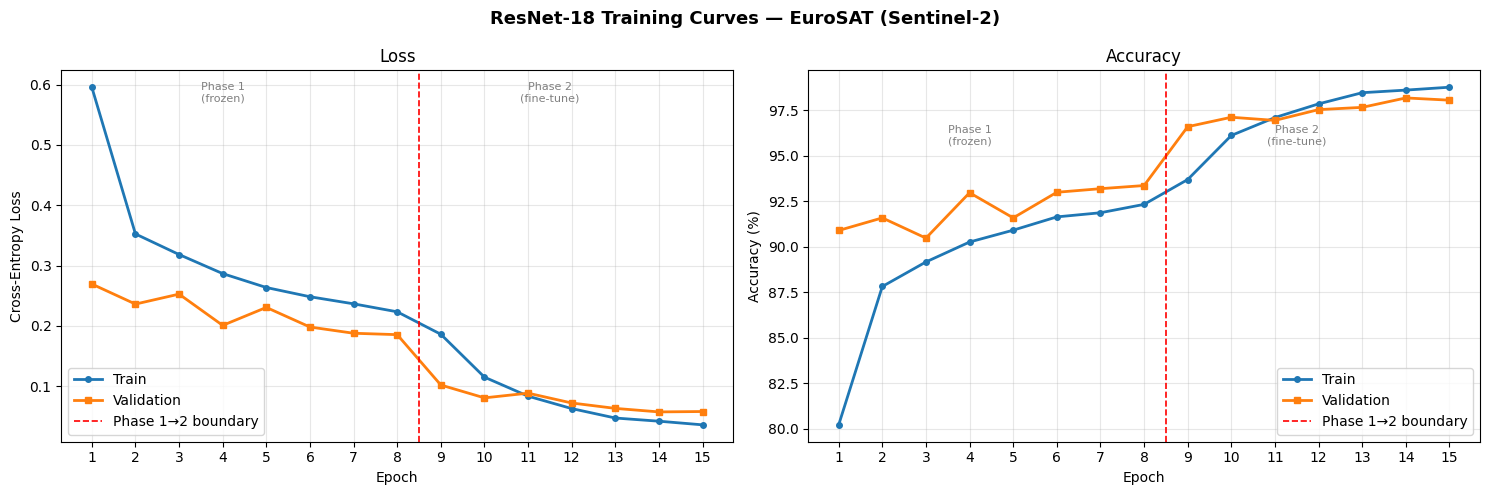

In [ ]:
# ── Training curves ──────────────────────────────────────────────────────
total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
ep_range     = range(1, total_epochs + 1)
phase_boundary = PHASE1_EPOCHS + 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet-18 Training Curves — EuroSAT (Sentinel-2)',
             fontsize=13, fontweight='bold')

for ax, metric, ylabel in [
    (ax1, ('train_loss', 'val_loss'), 'Cross-Entropy Loss'),
    (ax2, ('train_acc',  'val_acc'),  'Accuracy (%)')
]:
    tr_key, va_key = metric
    tr_vals = history[tr_key]
    va_vals = history[va_key]
    if 'acc' in tr_key:
        tr_vals = [v * 100 for v in tr_vals]
        va_vals = [v * 100 for v in va_vals]
    ax.plot(ep_range, tr_vals, 'o-', label='Train', linewidth=2, markersize=4)
    ax.plot(ep_range, va_vals, 's-', label='Validation', linewidth=2, markersize=4)
    ax.axvline(phase_boundary, color='red', linestyle='--', linewidth=1.2,
               label='Phase 1→2 boundary')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(ep_range))

ax1.set_title('Loss')
ax2.set_title('Accuracy')

# Annotate phase labels
for ax in [ax1, ax2]:
    ax.text(PHASE1_EPOCHS / 2, ax.get_ylim()[1] * 0.97,
            'Phase 1\n(frozen)', ha='center', va='top',
            fontsize=8, color='grey')
    ax.text(PHASE1_EPOCHS + PHASE2_EPOCHS / 2, ax.get_ylim()[1] * 0.97,
            'Phase 2\n(fine-tune)', ha='center', va='top',
            fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation on Held-Out Test Set

We load the best checkpoint (highest validation accuracy) and run inference
on the test set, which has been held out throughout all training phases.

**Reported metrics:**
- **Overall accuracy**: fraction of correctly classified patches
- **Per-class precision, recall, F1**: identifies which land cover types are
  harder to distinguish (e.g., AnnualCrop vs PermanentCrop)
- **Normalised confusion matrix**: cell (i, j) = fraction of class i
  predicted as class j — highlights systematic confusions

In [ ]:
# ── Load best checkpoint ─────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

# ── Collect predictions ───────────────────────────────────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()

print(f'Test Accuracy : {test_acc*100:.2f}%  ({(all_preds == all_labels).sum():,} / {len(all_labels):,} correct)\n')
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3
))

Test Accuracy : 97.88%  (3,964 / 4,050 correct)

                      precision    recall  f1-score   support

          AnnualCrop      0.977     0.979     0.978       472
              Forest      0.980     0.998     0.989       442
HerbaceousVegetation      0.974     0.963     0.968       458
             Highway      0.967     0.967     0.967       391
          Industrial      0.992     0.971     0.981       378
             Pasture      0.986     0.973     0.980       299
       PermanentCrop      0.959     0.979     0.969       379
         Residential      0.985     0.993     0.989       450
               River      0.978     0.968     0.973       375
             SeaLake      0.993     0.993     0.993       406

            accuracy                          0.979      4050
           macro avg      0.979     0.978     0.979      4050
        weighted avg      0.979     0.979     0.979      4050



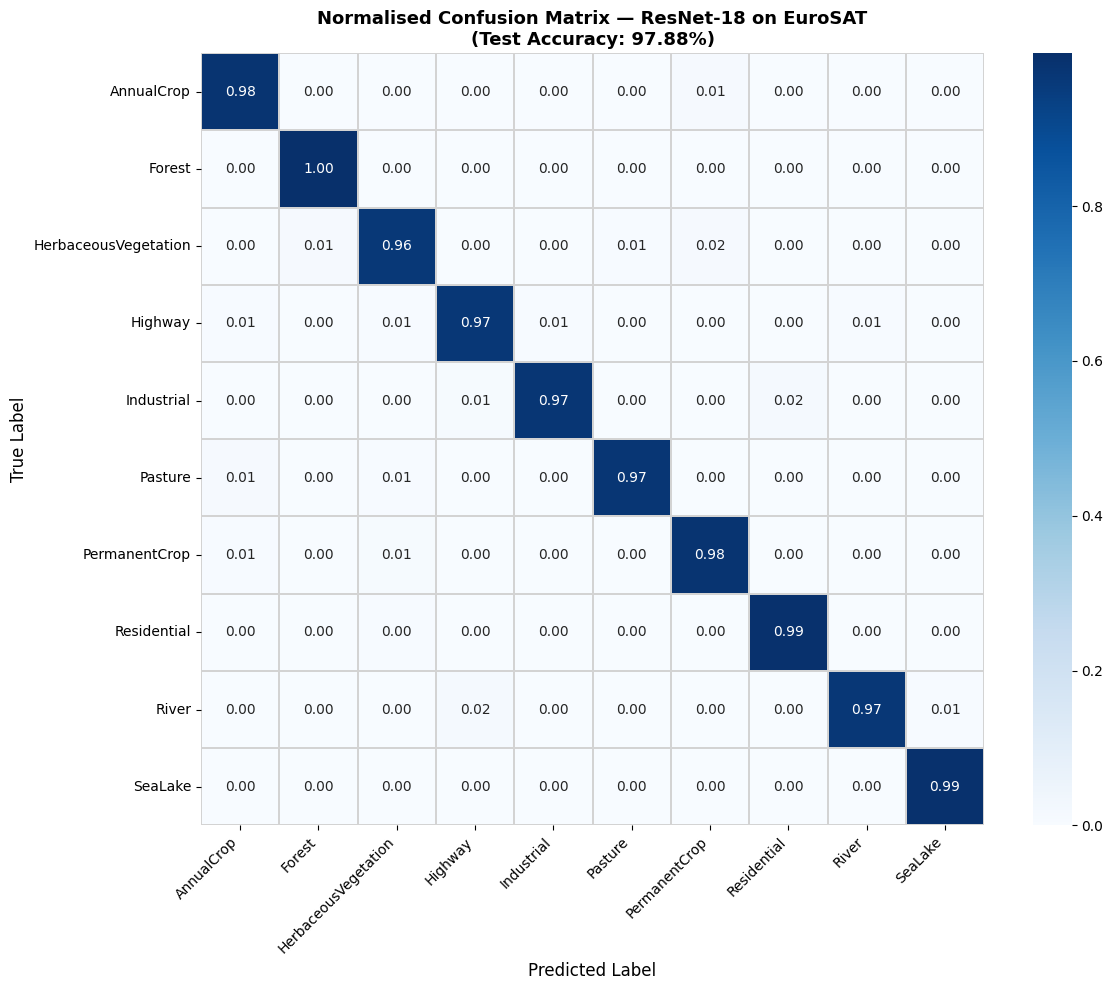

Most confused pair: true=River  →  pred=Highway  (1.9% misclassified)


In [ ]:
# ── Normalised confusion matrix ──────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.3, linecolor='lightgrey', ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(
    f'Normalised Confusion Matrix — ResNet-18 on EuroSAT\n'
    f'(Test Accuracy: {test_acc*100:.2f}%)',
    fontsize=13, fontweight='bold'
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Report worst-confused pairs
np.fill_diagonal(cm_norm, 0)
worst_idx = np.unravel_index(cm_norm.argmax(), cm_norm.shape)
print(f'Most confused pair: true={CLASS_NAMES[worst_idx[0]]}  →  pred={CLASS_NAMES[worst_idx[1]]}'
      f'  ({cm_norm[worst_idx]*100:.1f}% misclassified)')

## 9. GradCAM Attribution Maps

Gradient-weighted Class Activation Mapping (GradCAM; Selvaraju et al. 2017) computes
the gradient of the predicted class score with respect to the activations of the
target convolutional layer (`layer4`). The resulting heatmap highlights the spatial
regions that were most influential in the model's decision.

### Why GradCAM matters for poverty estimation

A model that highlights **building footprints and road networks** when predicting
Residential patches is relying on physically meaningful features.
A model that highlights **arbitrary background texture** is exploiting dataset artefacts.
GradCAM is therefore not merely a visualisation tool — it is a **model validation step**
before deployment in high-stakes policy applications.

This directly addresses the explainability objective in the target doctoral project:
transitioning SHAP (used for tree-based models) to GradCAM (convolutional models)
is the same epistemological act — building trust in EO-based estimates so that
policymakers can act on them.

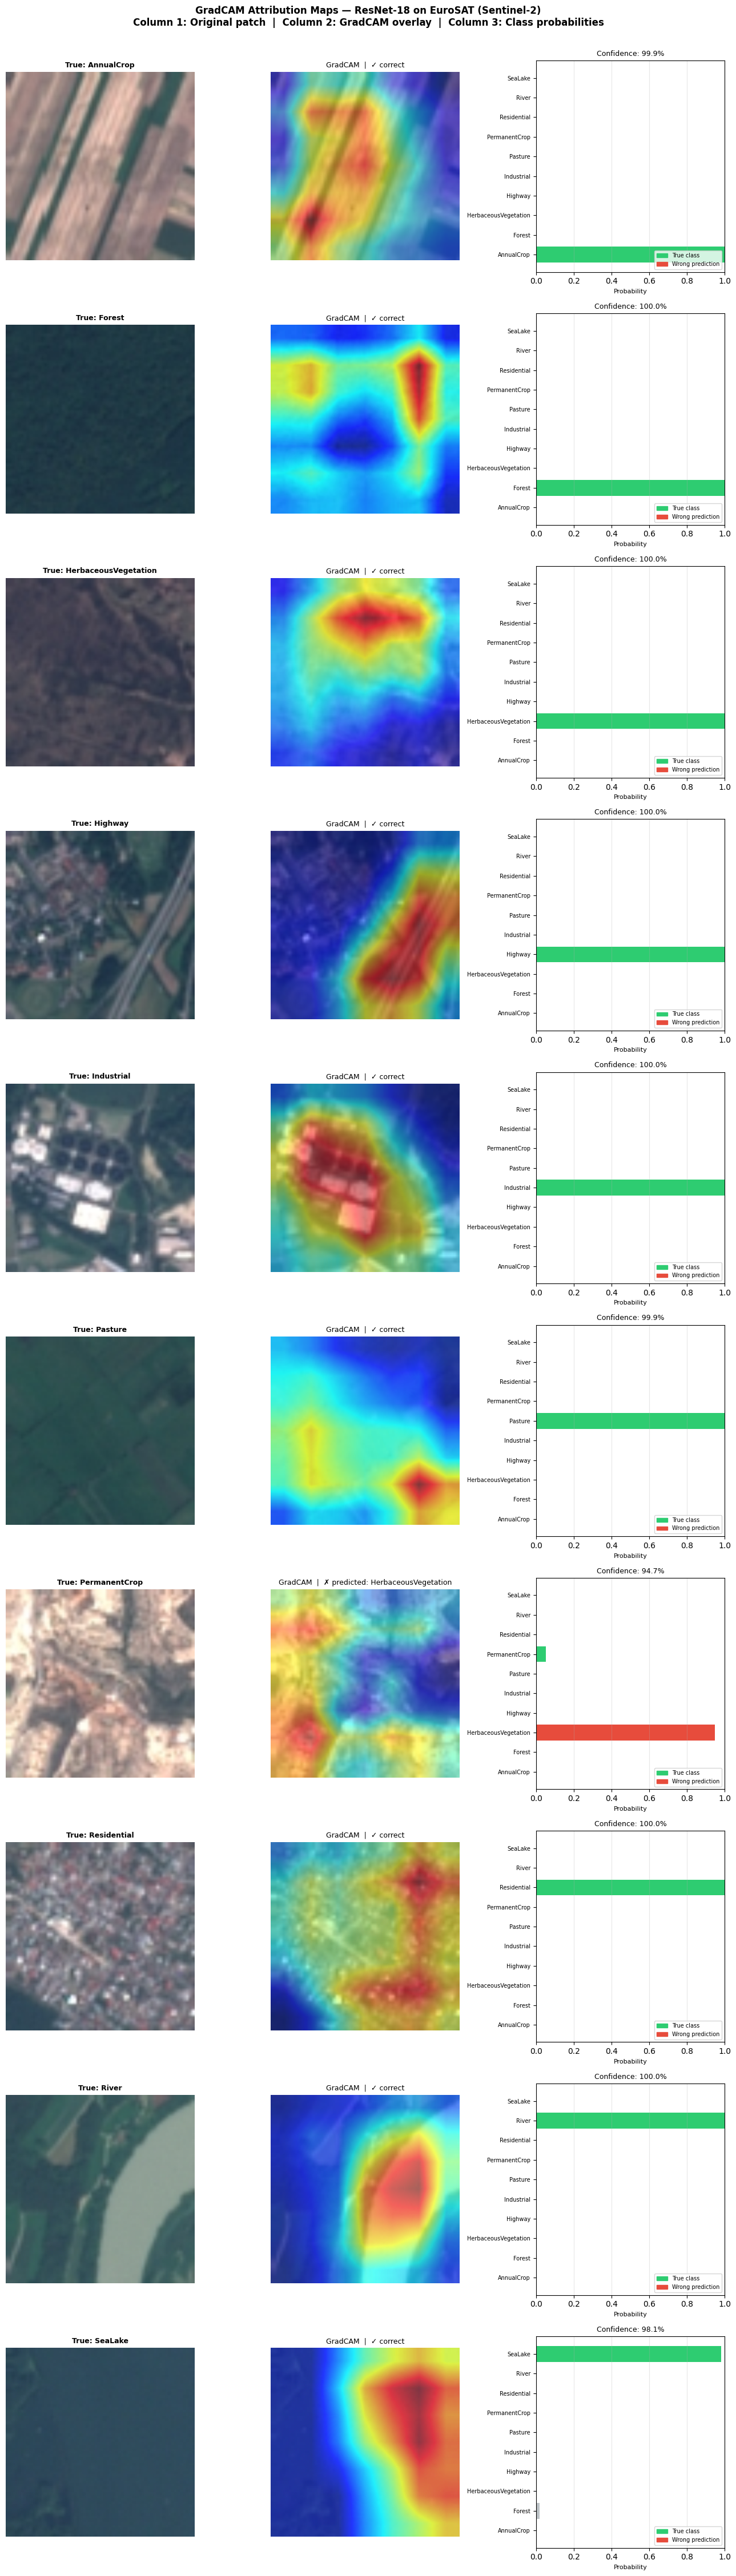

Fig saved: gradcam_attribution.png


In [ ]:
# ── GradCAM setup ────────────────────────────────────────────────────────
# Target: last residual block of ResNet-18.
# At 224×224 input, layer4 feature maps are 7×7 — good spatial resolution for
# GradCAM after bilinear upsampling to 224×224.
target_layers = [model.layer4[-1]]

# ── Select one test sample per class ─────────────────────────────────────
test_indices_by_class = {i: [] for i in range(NUM_CLASSES)}
for idx in test_ds.indices:
    lbl = full_dataset.targets[idx]
    test_indices_by_class[lbl].append(idx)

sample_indices = {cls: idxs[0] for cls, idxs in test_indices_by_class.items() if idxs}

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(13, 4.5 * NUM_CLASSES))
fig.suptitle(
    'GradCAM Attribution Maps — ResNet-18 on EuroSAT (Sentinel-2)\n'
    'Column 1: Original patch  |  Column 2: GradCAM overlay  |  Column 3: Class probabilities',
    fontsize=12, fontweight='bold', y=1.002
)

with GradCAM(model=model, target_layers=target_layers) as cam:
    for row, cls_idx in enumerate(range(NUM_CLASSES)):
        if cls_idx not in sample_indices:
            continue
        ds_idx = sample_indices[cls_idx]

        # Normalised image for model input
        img_norm, true_label = full_dataset[ds_idx]
        input_tensor = img_norm.unsqueeze(0).to(device)

        # Raw image for display (no normalisation)
        img_raw, _ = vis_dataset[ds_idx]
        img_display = img_raw.permute(1, 2, 0).numpy().clip(0, 1).astype(np.float32)

        # GradCAM heatmap
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(cls_idx)]
        )[0]
        cam_overlay = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

        # Model output probabilities
        with torch.no_grad():
            logits = model(input_tensor)
            probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_cls  = int(probs.argmax())
        correct   = (pred_cls == cls_idx)

        # ── Column 0: original ──────────────────────────────────────────
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f'True: {CLASS_NAMES[cls_idx]}', fontsize=9, fontweight='bold')
        axes[row, 0].axis('off')

        # ── Column 1: GradCAM overlay ────────────────────────────────────
        axes[row, 1].imshow(cam_overlay)
        result_str = '✓ correct' if correct else f'✗ predicted: {CLASS_NAMES[pred_cls]}'
        axes[row, 1].set_title(f'GradCAM  |  {result_str}', fontsize=9)
        axes[row, 1].axis('off')

        # ── Column 2: probability bar chart ──────────────────────────────
        bar_colours = ['#2ecc71' if i == cls_idx else
                       '#e74c3c' if (i == pred_cls and not correct) else
                       '#bdc3c7'
                       for i in range(NUM_CLASSES)]
        axes[row, 2].barh(range(NUM_CLASSES), probs, color=bar_colours)
        axes[row, 2].set_yticks(range(NUM_CLASSES))
        axes[row, 2].set_yticklabels(CLASS_NAMES, fontsize=7)
        axes[row, 2].set_xlabel('Probability', fontsize=8)
        axes[row, 2].set_title(f'Confidence: {probs[pred_cls]*100:.1f}%', fontsize=9)
        axes[row, 2].set_xlim(0, 1)
        axes[row, 2].grid(axis='x', alpha=0.3)
        # Legend patches
        patches = [
            mpatches.Patch(color='#2ecc71', label='True class'),
            mpatches.Patch(color='#e74c3c', label='Wrong prediction'),
        ]
        axes[row, 2].legend(handles=patches, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('gradcam_attribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fig saved: gradcam_attribution.png')

## 10. From Land Cover to Poverty Proxies

### What this pipeline demonstrates for poverty estimation

| Land Cover Class | Poverty Proxy Signal | Causal Interpretation |
|---|---|---|
| Residential | Building density, settlement structure | Correlates with population and urbanisation level |
| Industrial | Formal economic activity | Proxy for wage employment presence |
| Highway / River | Infrastructure access | Access to markets and services |
| Forest / Pasture | Low human modification | Often correlates with remoteness and low income |
| AnnualCrop | Subsistence vs commercial farming | Distinguishable via texture and field regularity |

The CNN trained here learns **discriminative spatial features** (building patterns,
road geometry, vegetation texture) that poverty estimation models use as wealth-index
proxies. The GradCAM maps show **which spatial regions** drive those decisions —
which is the explainability requirement for policy-grade EO-based estimates.

### The causal inference gap

A critical distinction: the model above is a **predictive** model. It learns that
metal roofs → Residential → higher wealth. But the roof is a *proxy*, not a causal lever.

Poverty estimation for policy requires moving from prediction to **causal inference**:
- *What intervention would change poverty levels?*
- *Is the association between satellite features and poverty confounded by geographic selection?*

Prediction-Powered Inference (PPI; Angelopoulos et al. 2023) addresses the case where
ground-truth poverty labels are scarce but ML predictions are abundant —
exactly the regime of global poverty mapping. PPI uses the ML predictions as a
first-stage imputation, then applies classical statistical inference with valid
uncertainty guarantees. This is the methodological bridge between the pipeline
demonstrated here and the doctoral research objectives.

### Connecting to informative missingness

In this notebook, if a patch from a remote highland region were missing from
the dataset, that absence would not be random — it would correlate with
low population density and restricted satellite tasking. That systematic
missingness mechanism is identical to the selection-on-observables problem
in causal inference, and treating it as informative rather than noise is the
statistical foundation on which valid poverty estimates depend.

## 11. Next Steps

This notebook establishes the CNN pipeline foundation. The following extensions
are planned for the doctoral research programme:

### Technical extensions
1. **Multi-spectral input**: Replace RGB (3 bands) with all 13 Sentinel-2 bands.
   Vegetation indices (NDVI, EVI) and SWIR bands add discriminative power for
   poverty proxies like bare soil and crop health.

2. **Temporal stacking**: Concatenate patches from multiple acquisition dates.
   Seasonal change detection identifies subsistence vs commercial agriculture
   and construction activity — key poverty dynamics.

3. **Direct poverty regression**: Replace the 10-class head with a regression
   head predicting a continuous wealth index (e.g., DHS asset index).
   This requires ground-truth survey data co-located with satellite patches.

4. **Prediction-Powered Inference**: Apply PPI (Angelopoulos et al. 2023) to
   produce confidence intervals for poverty estimates in regions with sparse
   ground-truth labels — the primary methodological target of the doctoral project.

5. **Geographic transfer**: Fine-tune on African Sentinel-2 imagery.
   The domain shift from European to African land cover requires adaptation
   of spectral normalisation and potentially few-shot fine-tuning.

### Reproducibility
All code is version-controlled at: `github.com/pujapoudyal`

### References
- Helber et al. (2019). EuroSAT: A Novel Dataset and Deep Learning Benchmark
  for Land Use and Land Cover Classification. *IEEE JSTARS*.
- Selvaraju et al. (2017). Grad-CAM: Visual Explanations from Deep Networks.
  *ICCV 2017*.
- Angelopoulos et al. (2023). Prediction-Powered Inference. *Science*.
- Jean et al. (2016). Combining satellite imagery and ML to predict poverty. *Science*.